## Installing uv

To start, you'll want to have uv installed:

https://docs.astral.sh/uv/getting-started/installation/


**Next, run this in the terminal, from the parent directory:**

    uv sync


Now you will have the kernel used to run this notebook

---

## Running the Required Servers

You need to run **three servers**, each in its own terminal:

- `central_server.py`
- `AS_server.py`
- `Ceos_server.py`

### 1. Activate the Virtual Environment

`uv` should have created a `.venv` directory for you.

**On macOS / Linux:**

    source .venv/bin/activate

**On Windows (likely):**

    source .venv/Scripts/activate

You should now see the environment activated.

---

### 2. Start the Servers

**Terminal 1 — Central Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.protocols.central_server

**Terminal 2 — Atom Resolution Simulation Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.AS_server

**Terminal 3 — CEOS Twin Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.Ceos_server

---

You're now ready to run this notebook! 🚀

In [1]:
import sys
import ast
import json
import time
import numpy as np
sys.path.insert(0, '../')
from asyncroscopy.clients.notebook_client import NotebookClient
from asyncroscopy.utils import parula_color_map
import matplotlib.pyplot as plt
from skimage.feature import blob_log
from scipy.ndimage import gaussian_filter
import pyTEMlib
from pyTEMlib import probe_tools as pt

%matplotlib ipympl

### Connections:

In [2]:
# Connect the Client to the central (async) server
tem = NotebookClient.connect(host='localhost', port=9000)

# Tell the central server address of all connected instruments
routing_table= {"AS": ("localhost", 9001),
                "Gatan": ("localhost", 9002),
                "Ceos": ("localhost", 9003),
                "Preacquired_AS": ("localhost", 9004)}
tem.send_command('Central',"set_routing_table", routing_table)

# ConnectionResetError: [Errno 54] Connection reset by peer 
# in terminal, type:
# lsof -i :9000
# then kill PIDs on that port


Connecting to central server localhost:9000...
Connected to central server.


'[Central] Routing table updated'

In [19]:
# connect to the microscope hardware computer and initialize microscope
tem.send_command('AS',command='connect_AS',args={'host':'10.46.217.241','port':9095})
params = tem.send_command(destination = 'Ceos', command = 'getInfo', args = {})
params = json.loads(params)
params

{'jsonrpc': '2.0',
 'result': {'host': '198.211.143.10',
  'mode': 'STEM',
  'version': 'v1.6-221-gbb906f58',
  'kernelProtocolVersion': [1, 12, 4],
  'currentSetting': 'MC_STEM@200KV',
  'currentLabel': 'calibrated',
  'measurementRange': {'We': 1.8609205752267538e-07,
   'A2': 4.038456289966122e-06,
   'B2': 2.019228144983061e-06},
  'correctorType': 'DCORPRIME',
  'kernelVersion': '5-6-373',
  'kernelHexVersion': 329589},
 'id': 1}

### Help commands:

In [12]:
# Now that we're routed to all instruments,
# let's take an inventory of commands available on each instrument
cmds = tem.send_command('AS', 'discover_commands')
print(cmds)

["blank_beam", "calibrate_screen_current", "connect_AS", "connectionLost", "connectionMade", "dataReceived", "disconnect", "discover_commands", "get_current", "get_help", "get_metadata", "get_scanned_image", "get_stage", "get_status", "lengthLimitExceeded", "logPrefix", "makeConnection", "pauseProducing", "place_beam", "resumeProducing", "sendString", "set_current", "stopProducing", "stringReceived", "tune_C1A1", "unblank_beam"]


### Getting the aberrations:

Do this at 225 kx

In [13]:
aberrations = tem.send_command(destination = 'Ceos', command = 'acquireTableau', args = {'tabType':"Fast", 'angle':18})
aberrations = json.loads(aberrations)
ab = aberrations['result']['aberrations']
ab

{'A1': [-1.5363389257483178e-09, 3.0099973855843406e-10],
 'A2': [6.035016551202449e-08, 5.539789580648325e-08],
 'B2': [4.311933565998621e-08, -1.022043831140847e-09],
 'C1': [-1.1737813950847595e-08, 0.0],
 'WD': [-0.0006222487460034929, 0.0011133008695894226]}

### Calibrate the probe fluence:

In [20]:
tem.send_command('AS', 'calibrate_screen_current')

'[AS] calibrated screen current'

In [96]:
# then set current to test
beam_current = 100 # pA
tem.send_command('AS', 'set_current', {'current':beam_current}) # pA

'[AS] current set to 100.0'

### Get an image:

Real image

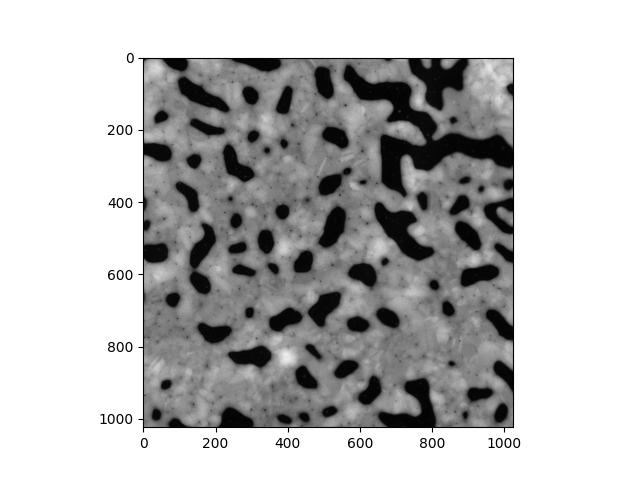

In [22]:
image_args = {'scanning_detector':'HAADF',
                'size':1024,
                'dwell_time':10e-6}

img = tem.send_command('AS','get_scanned_image', image_args)

plt.figure()
plt.imshow(img, cmap="gray")


In [23]:
# get pixel size
metadata = tem.send_command('AS', 'get_metadata')
metadata = ast.literal_eval(metadata)
pixel_size = metadata['last_pixel_size']

pixel_size # nm

0.36346104984897537

### The Experiment

We need to know electrons/area/time

electrons/area/time = current / (e * area)

we directly set and measure the current

we get area by measuring probe size!  How?  Through the aberrations!


In [101]:
current_vals = [20, 40, 60, 90, 140, 200, 500, 1000]
# current_vals = [10, 100, 500]
measured_vals = []
ab_list = []
images = []
for current in current_vals: # pA
    # set current
    print(f"Setting current to {current} pA")
    tem.send_command('AS', 'set_current', {'current':current}) # pA

    time.sleep(2)
    # measure current
    measured_current = tem.send_command('AS', 'get_current', {}) # pA
    measured_vals.append(measured_current)

    # focus
    print("focusing...")
    tem.send_command('AS','tune_C1A1')

    # log an image
    print("taking image...")
    image = tem.send_command('AS','get_scanned_image', image_args)
    images.append(image)

    # get probe size
    print("measuring aberrations...")
    aberrations = tem.send_command(destination = 'Ceos', command = 'acquireTableau', args = {'tabType':"Enhanced", 'angle':30})
    aberrations = json.loads(aberrations)
    ab = aberrations['result']['aberrations']
    ab_list.append(ab)

Setting current to 20 pA
focusing...
taking image...
measuring aberrations...
Setting current to 40 pA
focusing...
taking image...
measuring aberrations...
Setting current to 60 pA
focusing...
taking image...
measuring aberrations...
Setting current to 90 pA
focusing...
taking image...
measuring aberrations...
Setting current to 140 pA
focusing...
taking image...
measuring aberrations...
Setting current to 200 pA
focusing...
taking image...
measuring aberrations...
Setting current to 500 pA
focusing...
taking image...
measuring aberrations...
Setting current to 1000 pA
focusing...
taking image...
measuring aberrations...


In [121]:
import numpy as np

def convert_aberrations_A_to_C(ab):
    """
    Convert aberrations from A/B/S/D notation to Saxton Cnm notation.

    Input:
        ab : dict
            aberration dict in A1, A2, C3, etc format

    Returns:
        dict with Cnm notation populated
    """

    out = dict(ab)  # copy everything

    mapping = {

        # defocus
        "C1": ("C10",),

        # 2nd order
        "A1": ("C12a", "C12b"),

        # 3rd order
        "B2": ("C21a", "C21b"),
        "A2": ("C23a", "C23b"),

        # 4th order
        "C3": ("C30",),
        "S3": ("C32a", "C32b"),
        "A3": ("C34a", "C34b"),

        # 5th order
        "D4": ("C41a", "C41b"),
        "B4": ("C43a", "C43b"),
        "A4": ("C45a", "C45b"),

        # 6th order
        "C5": ("C50",),
        "A5": ("C56a", "C56b"),
    }

    for key, target in mapping.items():

        if key not in ab:
            continue

        val = ab[key]

        # symmetric terms
        if len(target) == 1:

            if isinstance(val, (list, tuple, np.ndarray)):
                out[target[0]] = float(val[0]* 1e9)
            else:
                out[target[0]] = float(val* 1e9)

        # angular terms
        elif len(target) == 2:

            out[target[0]] = float(val[0]* 1e9)
            out[target[1]] = float(val[1]* 1e9)

    return out

-9.897123325833753
Acceleration voltage 200.0kV  => wavelength 2.51pm
2.9999999999999997e-05
-1.1565052428152427
Acceleration voltage 200.0kV  => wavelength 2.51pm
2.9999999999999997e-05
-1.095346710126918
Acceleration voltage 200.0kV  => wavelength 2.51pm
2.9999999999999997e-05
0.6884359104833414
Acceleration voltage 200.0kV  => wavelength 2.51pm
2.9999999999999997e-05
-0.033522664284528325
Acceleration voltage 200.0kV  => wavelength 2.51pm
2.9999999999999997e-05
0.15004093525790113
Acceleration voltage 200.0kV  => wavelength 2.51pm
2.9999999999999997e-05
0.8694668629635454
Acceleration voltage 200.0kV  => wavelength 2.51pm
2.9999999999999997e-05
1.4062675939982978
Acceleration voltage 200.0kV  => wavelength 2.51pm
2.9999999999999997e-05


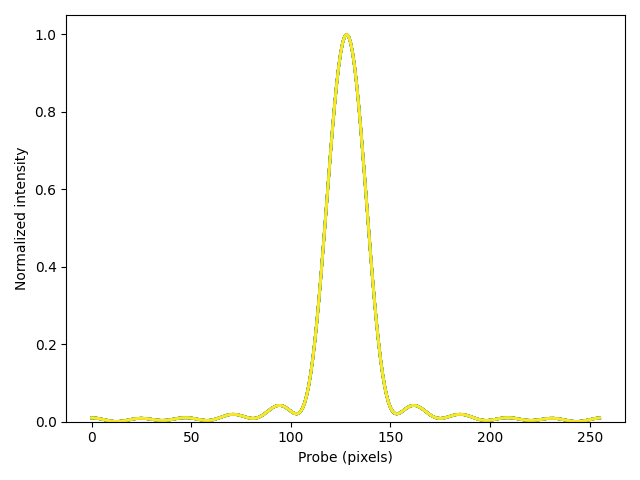

In [122]:
probes = []
ab_list_converted = []
for ab in ab_list:
    ab = convert_aberrations_A_to_C(ab)
    ab['acceleration_voltage'] = 200e3
    ab['convergence_angle'] = 30e-3
    ab['FOV'] = 500
    print(ab['C10'])
    ab_list_converted.append(ab)
    probe, A_k, chi  = pt.get_probe(ab, 256, 256, verbose= True)
    probes.append(probe)
    
profiles = [np.sum(p, axis=0) for p in probes]

cmap = plt.get_cmap("viridis")   # or "plasma", "cividis", etc.
colors = cmap(np.linspace(0, 1, len(profiles)))

x_vals = np.arange(profiles[0].shape[0]) * pixel_size
plt.figure()
for profile, color in zip(profiles, colors):
    plt.plot(profile / profile.max(), color=color, linewidth=2)
plt.xlabel("Probe (pixels)")
plt.ylabel("Normalized intensity")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [123]:
# save abs, measured currents, set currents
import pandas as pd

df = pd.DataFrame({
    'set_current_pA': current_vals,
    'measured_current_pA': measured_vals,
    'aberrations': ab_list_converted
})
df.to_csv("probe_aberrations.csv", index=False)



In [124]:
# save images
im_array = np.stack(images)
np.save("calibration_images.npy", im_array)

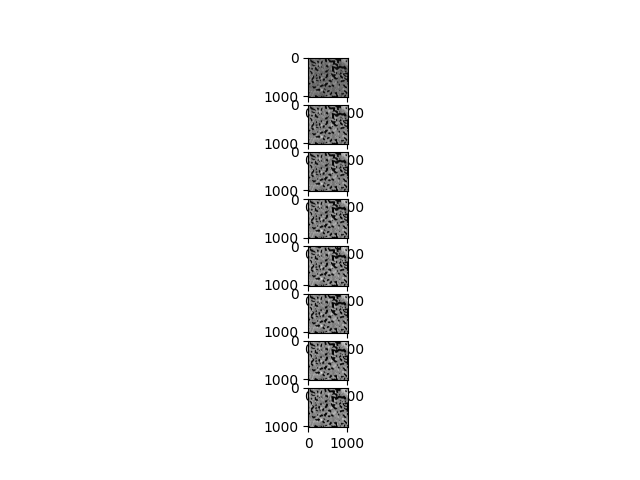

In [106]:
fig, ax = plt.subplots(len(images),1)
for i, image in enumerate(images):
    ax[i].imshow(image, cmap="gray")

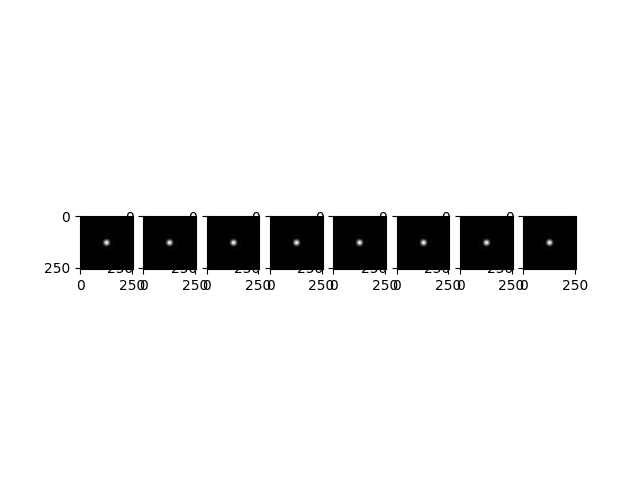

In [118]:
fig, ax = plt.subplots(1, len(probes))
for i, image in enumerate(probes):
    ax[i].imshow(image, cmap="gray")
    